# **SIGK Increasing image resolution**

### Import Dataset DIV2K

In [2]:
import os
from typing import Any, Tuple
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset
from torchvision import transforms


class ImageDataset(Dataset):
    def __init__(self, root: str, noise_level: float = None, input_size: Tuple[int, int] = None):
        self.root = root
        self.image_paths = [
            os.path.join(root, f) for f in os.listdir(root) if f.endswith(".png")
        ]
        self.transform = transforms.ToTensor()
        if noise_level and input_size:
            raise ValueError("Only one value can be set at the same time.")
        self.noise_level = noise_level
        self.input_size = input_size

    def __len__(self) -> int:
        return len(self.image_paths)

    def __getitem__(self, idx) -> Tuple[torch.Tensor, torch.Tensor]:
        img_path = self.image_paths[idx]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = self.__resize(img, (256, 256))
        if self.input_size is not None:
            modified_img = self.__resize(img, self.input_size)
            modified_img = modified_img.astype(np.float32) / 255.0
            modified_img = self.transform(modified_img)

        img = img.astype(np.float32) / 255.0
        img = self.transform(img)

        if self.noise_level is not None:
            modified_img = self.__add_noise(img, self.noise_level)

        return modified_img, img

    def __add_noise(self, img: torch.Tensor, noise_level: float = 0.1) -> torch.Tensor:
        noise = torch.randn_like(img) * noise_level
        noisy_img = img + noise
        noisy_img = torch.clamp(noisy_img, 0.0, 1.0)
        return noisy_img

    def __resize(self, img: Any, size: Tuple[int, int]) -> Any:
        img = cv2.resize(img, size)
        return img

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
%env DATASET_PATH=/content/drive/MyDrive/SIGK

env: DATASET_PATH=/content/drive/MyDrive/SIGK


In [7]:
from torch.utils.data import DataLoader

noise = 0.1
resolution = [32, 32]
train_dataset = ImageDataset(f"{os.getenv('DATASET_PATH')}/DIV2K_train_HR", input_size=resolution)
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=False, num_workers=0)

valdiation_dataset = ImageDataset(f"{os.getenv('DATASET_PATH')}/DIV2K_valid_HR", input_size=resolution)
valdiation_dataloader = DataLoader(valdiation_dataset, batch_size=16, shuffle=False, num_workers=0)

Example dataset images

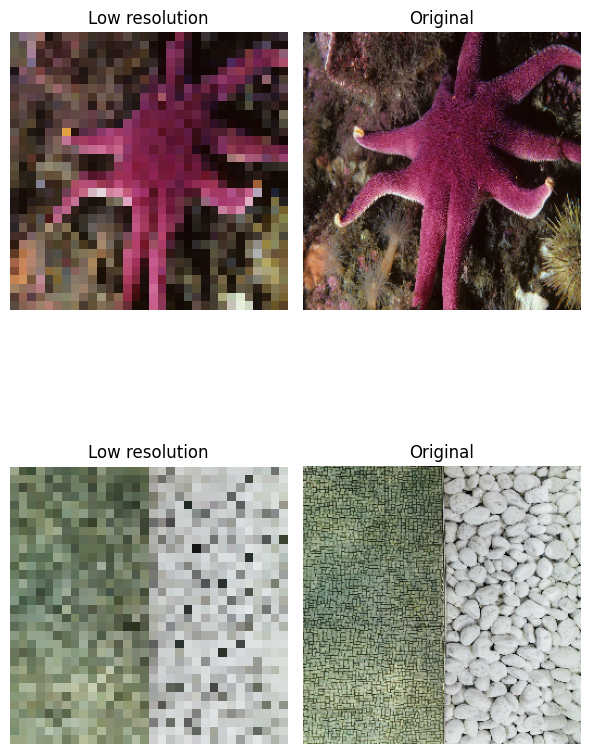

In [9]:
import matplotlib.pyplot as plt

x, y = next(iter(train_dataloader))

num_samples = 2
fig, axs = plt.subplots(num_samples, 2, figsize=(6, 10))

for i in range(num_samples):
    axs[i, 0].imshow(x[i].permute(1, 2, 0))
    axs[i, 0].set_title("Low resolution")
    axs[i, 0].axis("off")

    axs[i, 1].imshow(y[i].permute(1, 2, 0))
    axs[i, 1].set_title("Original")
    axs[i, 1].axis("off")

plt.tight_layout()
plt.show()

### SR model SRUNet


In [10]:
import torch
import torch.nn as nn
from typing import Optional

class SRUNet(nn.Module):

    def __init__(
        self,
        in_channels: int = 3,
        out_channels: int = 3,
        init_features: int = 64,
        use_bnorm: bool = True,
        input_size: int = 32
    ):
        upscale_factor = 256 // 32
        super(SRUNet, self).__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.init_features = init_features
        self.upscale_factor = upscale_factor
        self.use_bnorm = use_bnorm

        features = init_features

        self.encoder1 = self._make_conv_block(in_channels, features)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.encoder2 = self._make_conv_block(features, features * 2)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.encoder3 = self._make_conv_block(features * 2, features * 4)
        self.pool3 = nn.MaxPool2d(2, 2)

        self.bottleneck = self._make_conv_block(features * 4, features * 8)

        self.upconv3 = nn.ConvTranspose2d(features * 8, features * 4, kernel_size=2, stride=2)
        self.decoder3 = self._make_conv_block(features * 8, features * 4)

        self.upconv2 = nn.ConvTranspose2d(features * 4, features * 2, kernel_size=2, stride=2)
        self.decoder2 = self._make_conv_block(features * 4, features * 2)

        self.upconv1 = nn.ConvTranspose2d(features * 2, features, kernel_size=2, stride=2)
        self.decoder1 = self._make_conv_block(features * 2, features)

        self.sr_layers = self._make_sr_layers(features, upscale_factor)

        self.final_conv = nn.Conv2d(features, out_channels, kernel_size=3, padding=1)


    def _make_conv_block(self, in_channels: int, out_channels: int):
        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=not self.use_bnorm),
            nn.BatchNorm2d(out_channels) if self.use_bnorm else nn.Identity(),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=not self.use_bnorm),
            nn.BatchNorm2d(out_channels) if self.use_bnorm else nn.Identity(),
            nn.ReLU(inplace=True)
        ]
        return nn.Sequential(*layers)

    def _make_sr_layers(self, features: int, upscale_factor: int):
        layers = []

        num_upsample = 0
        factor = upscale_factor
        while factor > 1:
            if factor % 2 == 0:
                num_upsample += 1
                factor //= 2
            else:
                raise ValueError(f"Upscale factor {upscale_factor} must be a power of 2")

        for i in range(num_upsample):
            layers.extend([
                nn.ConvTranspose2d(features, features, kernel_size=4, stride=2, padding=1),
                nn.BatchNorm2d(features) if self.use_bnorm else nn.Identity(),
                nn.ReLU(inplace=True),
                nn.Conv2d(features, features, kernel_size=3, padding=1),
                nn.BatchNorm2d(features) if self.use_bnorm else nn.Identity(),
                nn.ReLU(inplace=True)
            ])

        return nn.Sequential(*layers)

    def forward(self, x):
        enc1 = self.encoder1(x)
        enc2 = self.encoder2(self.pool1(enc1))
        enc3 = self.encoder3(self.pool2(enc2))

        bottleneck = self.bottleneck(self.pool3(enc3))

        dec3 = self.upconv3(bottleneck)
        dec3 = torch.cat([dec3, enc3], dim=1)
        dec3 = self.decoder3(dec3)

        dec2 = self.upconv2(dec3)
        dec2 = torch.cat([dec2, enc2], dim=1)
        dec2 = self.decoder2(dec2)

        dec1 = self.upconv1(dec2)
        dec1 = torch.cat([dec1, enc1], dim=1)
        dec1 = self.decoder1(dec1)

        sr_output = self.sr_layers(dec1)

        output = self.final_conv(sr_output)

        return output

### SRUNet loss functions

In [11]:
"""
Loss functions for image denoising
Includes Perceptual Loss and Charbonnier Loss
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import vgg16


class CharbonnierLoss(nn.Module):

    def __init__(self, epsilon: float = 1e-3, reduction: str = 'mean'):
        super(CharbonnierLoss, self).__init__()
        self.epsilon = epsilon
        self.reduction = reduction

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        diff = pred - target
        loss = torch.sqrt(diff * diff + self.epsilon * self.epsilon)

        return torch.mean(loss)


class PerceptualLoss(nn.Module):
    def __init__(self):
        super(PerceptualLoss, self).__init__()
        vgg = vgg16(pretrained=True).features[:16]
        for param in vgg.parameters():
            param.requires_grad = False
        self.vgg = vgg.eval()

    def forward(self, denoised, gt):
        denoised_features = self.vgg(denoised)
        gt_features = self.vgg(gt)
        loss = F.mse_loss(denoised_features, gt_features)
        return loss


class CombinedLoss(nn.Module):

    def __init__(
        self,
        charbonnier_loss: nn.Module,
        perceptual_loss: nn.Module,
        mse_weight: float = 1.0,
        charbonnier_weight: float = 1.0,
        perceptual_weight: float = 0.1
    ):
        super(CombinedLoss, self).__init__()
        self.mse_weight = mse_weight
        self.charbonnier_loss = charbonnier_loss
        self.perceptual_loss = perceptual_loss
        self.charbonnier_weight = charbonnier_weight
        self.perceptual_weight = perceptual_weight

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        mse_loss = nn.MSELoss()(pred, target)
        loss = self.charbonnier_weight * self.charbonnier_loss(pred, target)
        loss += mse_loss * self.mse_weight
        if self.perceptual_loss is not None:
            loss += self.perceptual_weight * self.perceptual_loss(pred, target)

        return loss


def get_charbonnier_loss() -> CharbonnierLoss:
    return CharbonnierLoss()

In [12]:
import torch
import time
from tqdm import tqdm
import random
import numpy as np

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def train_epoch(model, loader, criterion, optimizer, device, epoch=None):
    model.train()
    total_loss = 0
    start_time = time.time()

    for batch_idx, (x, y) in tqdm(enumerate(loader)):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if batch_idx % 10 == 0:
            print(f"Epoch {epoch}, Batch {batch_idx}/{len(loader)}, "
                       f"Batch Loss: {loss.item():.6f}")

    avg_loss = total_loss / len(loader)
    epoch_time = time.time() - start_time
    print(f"Epoch {epoch} Training - Avg Loss: {avg_loss:.6f}, "
                   f"Time: {epoch_time:.2f}s")

    return avg_loss

def validate(model, loader, criterion, device, epoch=None):
    model.eval()
    total_loss = 0
    batch_count = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)

            total_loss += loss.item()
            batch_count += 1

    avg_loss = total_loss / batch_count
    print(f"Epoch {epoch} Validation - Loss: {avg_loss:.6f}")

    return avg_loss

### SRUNet Training function

In [13]:
import torch
from torch.utils.data import DataLoader
import time
from datetime import datetime


def train_model(data, model, device, epochs=7):
    train_loader = data

    criterion = nn.MSELoss()

    print("Loss Configuration:")

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-4,
        weight_decay=1e-5
    )

    print("Optimizer: Adam, LR: 1e-4, Weight Decay: 1e-5")
    print("-" * 80)

    best_val_loss = float("inf")
    training_start_time = time.time()

    for epoch in range(epochs):
        epoch_start_time = time.time()
        print(f"Starting Epoch {epoch + 1}/{epochs}")

        train_loss = train_epoch(model, train_loader, criterion, optimizer, device, epoch + 1)

        epoch_time = time.time() - epoch_start_time
        total_time = time.time() - training_start_time

        print(f"Epoch {epoch + 1} Summary:")
        print(f"  Train Loss: {train_loss:.6f}")
        print(f"  Epoch Time: {epoch_time:.2f}s")
        print(f"  Total Time: {total_time:.2f}s")
        print(f"  Estimated remaining: {(total_time / (epoch + 1) * (epochs - epoch - 1)):.2f}s")

        print("-" * 40)

    total_training_time = time.time() - training_start_time
    print(f"Best validation loss: {best_val_loss:.6f}")
    model_filename = "best_model_SRunet_init"
    model_filename += ".pth"
    torch.save(model.state_dict(), model_filename)
    print(f"Final model saved as: {model_filename}")

    print("="*80)
    print("TRAINING COMPLETED")
    print(f"Total training time: {total_training_time:.2f}s ({total_training_time/60:.1f} min)")
    print(f"Average time per epoch: {total_training_time/epochs:.2f}s")
    print(f"Best validation loss: {best_val_loss:.6f}")
    print(f"Final model saved as: {model_filename}")

    return best_val_loss

# Training SRUNet model

In [14]:
epochs = 4

print("="*80)
print("SRUNet Training Experiment")
print(f"Epochs: {epochs}")
print(f"Start Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

print("="*80)

set_seed(42)

print(f"Total images found: {len(train_dataset)}")


print("Starting training...")
experiment_start_time = time.time()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SRUNet(
        in_channels=3,
        init_features=128,
        input_size=32
    ).to(device)

best_training_loss = train_model(train_dataloader, model, device, epochs)

experiment_total_time = time.time() - experiment_start_time

print("="*80)
print("EXPERIMENT COMPLETED")
print(f"Total experiment time: {experiment_total_time:.2f}s ({experiment_total_time/60:.1f} min)")
print(f"Best training loss: {best_training_loss:.6f}")
print(f"End Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)

SRUNet Training Experiment
Epochs: 7
Start Time: 2025-11-02 16:15:37
Total images found: 800
Starting training...
Loss Configuration:
Optimizer: Adam, LR: 1e-4, Weight Decay: 1e-5
--------------------------------------------------------------------------------
Starting Epoch 1/7


1it [00:03,  3.35s/it]

Epoch 1, Batch 0/50, Batch Loss: 0.452429


11it [00:38,  3.70s/it]

Epoch 1, Batch 10/50, Batch Loss: 0.052971


...

Epoch 7, Batch 30/50, Batch Loss: 0.016974


41it [01:15,  1.86s/it]

Epoch 7, Batch 40/50, Batch Loss: 0.022450


50it [01:31,  1.83s/it]

Epoch 7 Training - Avg Loss: 0.020698, Time: 91.55s
Epoch 7 Summary:
  Train Loss: 0.020698
  Epoch Time: 91.55s
  Total Time: 721.29s
  Estimated remaining: 0.00s
----------------------------------------
Best validation loss: inf
Final model saved as: best_model_SRunet_init.pth
TRAINING COMPLETED
Total training time: 721.29s (12.0 min)
Average time per epoch: 103.04s
Best validation loss: inf
Final model saved as: best_model_SRunet_init.pth
EXPERIMENT COMPLETED
Total experiment time: 721.89s (12.0 min)
Best training loss: inf
End Time: 2025-11-02 16:27:39


In [33]:
def upscale_image(model, image, device):
    model.eval()
    with torch.no_grad():
        noisy_image = image.to(device)
        denoised = model(noisy_image)

    return denoised

def visualize_image(original, downscaled, upscaled, n=2):

    original = original.permute(0, 2, 3, 1).cpu()
    downscaled    = downscaled.permute(0, 2, 3, 1).cpu()
    upscaled = upscaled.permute(0, 2, 3, 1).cpu()

    k = min(n, len(original), len(downscaled), len(upscaled))
    for i in range(k):
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(downscaled[i].clip(0, 1).squeeze())       # handles 1-ch too
        axes[0].set_title("Downscaled")
        axes[0].axis("off")

        axes[1].imshow(upscaled[i].clip(0, 1).squeeze())
        axes[1].set_title("Upscaled")
        axes[1].axis("off")

        axes[2].imshow(original[i].clip(0, 1).squeeze())
        axes[2].set_title("Ground Truth")
        axes[2].axis("off")

        plt.tight_layout()
        plt.show()


In [16]:
import gc
gc.collect()
torch.cuda.empty_cache()

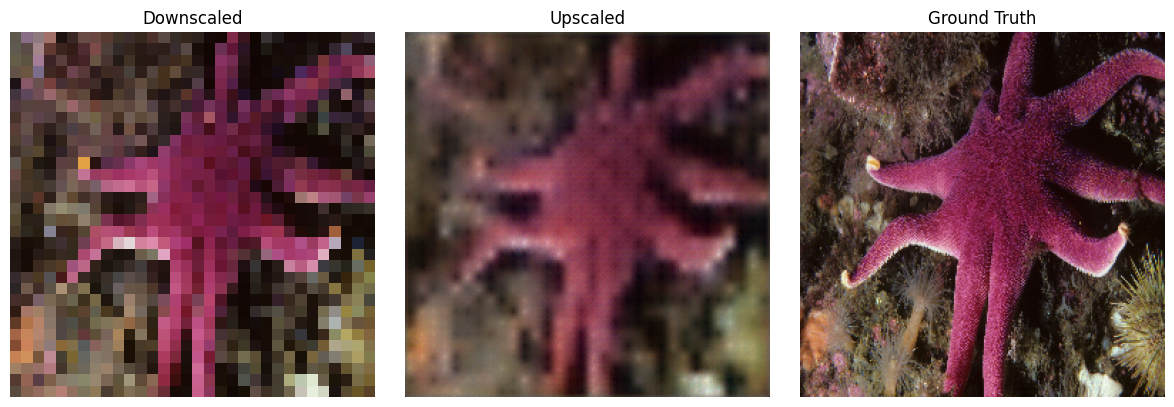

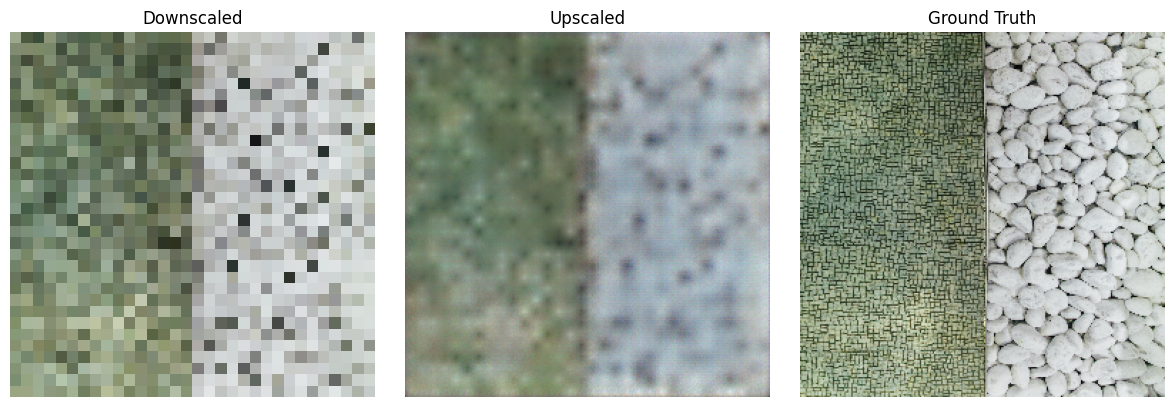

In [17]:
downscaled_image, original_image = next(iter(train_dataloader))

upscaled_image = upscale_image(model, downscaled_image, device)
visualize_image(original_image, downscaled_image, upscaled_image)

### Evaluating metrics for SRUNet model

In [18]:
!pip install -q lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.4 MB/s eta 0:00:00


In [23]:
import math
import numpy as np
from math import log10, sqrt
from skimage.metrics import structural_similarity as ssim
import lpips
from torch.utils.data import DataLoader

def SNE(original, generated):
    diff = original - generated
    sne = (diff ** 2).sum()
    return sne

def evaluate_SNE(model: nn.Module, data: DataLoader, device: str):
    model.eval()
    total_score = 0
    num_batches = 0
    with torch.no_grad():
        for modified_img, original_img in data:
            modified_img, original_img = modified_img.to(device), original_img.to(device)
            generated_img = model(modified_img)

            score = SNE(generated_img, original_img)

            total_score += score
            num_batches += 1
    average_score = total_score / num_batches
    print(f"Average SNE: {average_score:.6f}")
    return average_score

def PSNR(original, generated):
    mse = SNE(original, generated)
    if(mse == 0):
        return float("inf")
    max_pixel = 1
    psnr = 20 * log10(max_pixel / sqrt(mse))
    return psnr


def evaluate_PSNR(model: nn.Module, data: DataLoader, device: str):
    model.eval()
    total_score = 0
    num_batches = 0
    with torch.no_grad():
        for modified_img, original_img in data:
            modified_img, original_img = modified_img.to(device), original_img.to(device)
            generated_img = model(modified_img)

            score = PSNR(generated_img, original_img)
            total_score += score
            num_batches += 1
    average_score = total_score / num_batches
    print(f"Average PSNR: {average_score:.2f} dB")
    return average_score

def SSIM(original: torch.Tensor, generated: torch.Tensor) -> float:
    original_np = original.detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy()
    generated_np = generated.detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy()

    score = ssim(original_np, generated_np, data_range=1.0, channel_axis=2)
    return float(score)



def evaluate_SSIM(model: torch.nn.Module, data: torch.utils.data.DataLoader, device: str) -> float:
    model.eval()
    total_score = 0.0
    num_images = 0

    for modified_img, original_img in data:
        modified_img = modified_img.to(device)
        original_img = original_img.to(device)
        generated_img = model(modified_img)

        for i in range(generated_img.size(0)):
            score = SSIM(generated_img[i], original_img[i])
            total_score += score
            num_images += 1

    average_score = total_score / max(num_images, 1)
    print(f"Average SSIM: {average_score:.4f}")
    return average_score


def evaluate_LPIPS(model: nn.Module, data: DataLoader, device: str):

    model.eval()
    total_score = 0
    num_batches = 0
    with torch.no_grad():
        for modified_img, original_img in data:
            modified_img, original_img = modified_img.to(device), original_img.to(device)
            generated_img = model(modified_img)

            LPIPS = lpips.LPIPS(net='vgg').to(device)
            score = (LPIPS(generated_img, original_img)).mean()
            print(score)
            total_score += score
            num_batches += 1
    average_score = total_score / num_batches
    print(f"Average LPIPS: {average_score:.4f}")
    return average_score


In [20]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [24]:
avg_psnr = evaluate_PSNR(model, valdiation_dataloader, device)
avg_sne = evaluate_SNE(model, valdiation_dataloader, device)

Average PSNR: -47.59 dB
Average SNE: 60189.765625


In [54]:
avg_ssim = evaluate_SSIM(model, valdiation_dataloader, device)
torch.cuda.empty_cache()

Average SSIM: 0.3139


In [55]:
avg_lpips = evaluate_LPIPS(model, valdiation_dataloader, device)

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 237MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
tensor(0.6231, device='cuda:0')
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
tensor(0.6422, device='cuda:0')
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
tensor(0.6171, device='cuda:0')
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
tensor(0.6145, device='cuda:0')
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
tensor(0.6486, device='cuda:0')
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist

### Built in upscaling method

In [46]:
import torch
import torch.nn as nn
import numpy as np
import cv2

class UpscaleCV(nn.Module):
    def __init__(self, target_resolution):
        super().__init__()
        self.resolution = target_resolution

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        device = x.device
        x_np = x.detach().cpu().numpy()
        upscaled_batch = []
        for img in x_np:
            img = np.moveaxis(img, 0, -1)
            upscaled = cv2.resize(img, self.resolution, interpolation=cv2.INTER_CUBIC)
            upscaled = np.moveaxis(upscaled, -1, 0)  # back to (C, H, W)
            upscaled_batch.append(upscaled)

        upscaled_batch = np.stack(upscaled_batch, axis=0)  # (B, C, H, W)
        return torch.tensor(upscaled_batch, dtype=torch.float32, device=device)

### Comparison of SRUNet model to openCV bicupic interpolation method

In [47]:
downscaled_image, original_image = next(iter(train_dataloader))

In [49]:
Upscaler = UpscaleCV([256, 256]).to(device)

upscaled_images_with_bicubic = upscale_image(Upscaler, downscaled_image, device)
upscaled_images_with_model = upscale_image(model, downscaled_image, device)

In [41]:
def compare_images(original, downscaled, upscaled_CV, upscaled_model, n=2):

    original = original.permute(0, 2, 3, 1).cpu()
    downscaled    = downscaled.permute(0, 2, 3, 1).cpu()
    upscaled_model = upscaled_model.permute(0, 2, 3, 1).cpu()
    upscaled_CV = upscaled_CV.permute(0, 2, 3, 1).cpu()

    k = min(n, len(original), len(downscaled), len(upscaled_CV))
    for i in range(k):
        fig, axes = plt.subplots(1, 4, figsize=(12, 4))
        axes[0].imshow(downscaled[i].clip(0, 1).squeeze())
        axes[0].set_title("Downscaled")
        axes[0].axis("off")

        axes[1].imshow(upscaled_model[i].clip(0, 1).squeeze())
        axes[1].set_title("Upscaled with SRUNet")
        axes[1].axis("off")

        axes[2].imshow(upscaled_CV[i].clip(0, 1).squeeze())
        axes[2].set_title("Upscaled with bicubic interpolation")
        axes[2].axis("off")

        axes[3].imshow(original[i].clip(0, 1).squeeze())
        axes[3].set_title("Ground Truth")
        axes[3].axis("off")

        plt.tight_layout()
        plt.show()


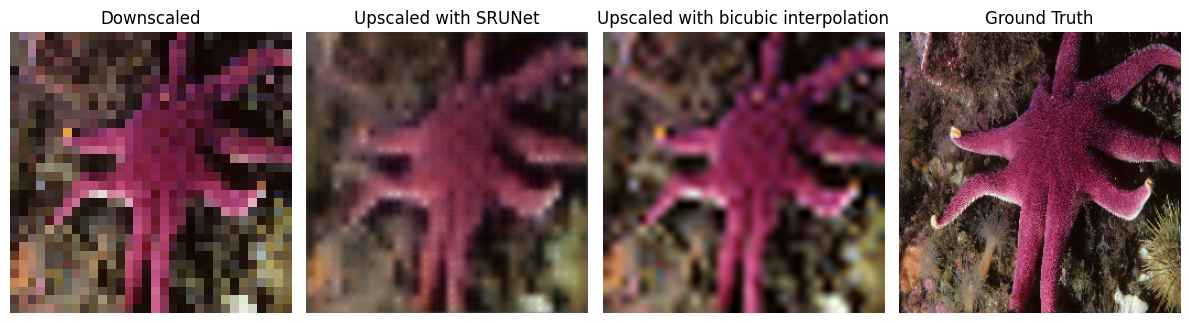

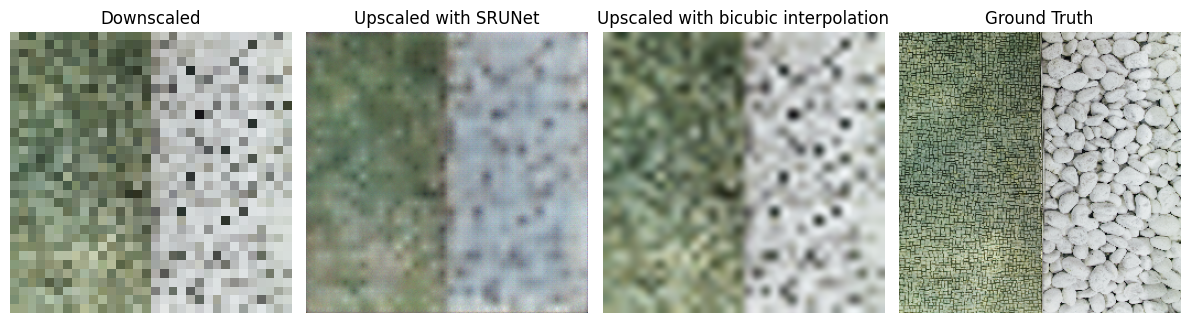

In [50]:
compare_images(original_image, downscaled_image, upscaled_images_with_bicubic, upscaled_images_with_model)

In [53]:
avg_psnr_bicubic = evaluate_PSNR(Upscaler, valdiation_dataloader, device)
avg_sne_bicubic = evaluate_SNE(Upscaler, valdiation_dataloader, device)

Average PSNR: -47.36 dB
Average SNE: 56727.195312


In [60]:
avg_ssim_bicubic = evaluate_SSIM(Upscaler, valdiation_dataloader, device)
torch.cuda.empty_cache()

Average SSIM: 0.4067


In [56]:
avg_lpips_bicubic = evaluate_LPIPS(Upscaler, valdiation_dataloader, device)

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
tensor(0.5771, device='cuda:0')
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
tensor(0.6048, device='cuda:0')
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
tensor(0.5616, device='cuda:0')
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
tensor(0.5852, device='cuda:0')
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
tensor(0.6040, device='cuda:0')
Setting up [LPIPS] perceptual loss: trunk [vgg], v

Bicubic interpolation vs SRUNet metrics

In [62]:
print("Compare Bicubic interpolation vs SRUNet net")
print("PSNR")
print(f"Bicubic interpolation: {avg_psnr_bicubic:.2f}dB || SRUNet: {avg_psnr:.2f}dB")

Compare Bicubic interpolation vs SRUNet net
PSNR
Bicubic interpolation: -47.36dB || SRUNet: -47.59dB


In [63]:
print("SNE")
print(f"Bicubic interpolation: {avg_sne_bicubic:.2f} || SRUNet: {avg_sne:.2f}")

SNE
Bicubic interpolation: 56727.20 || SRUNet: 60189.77


In [64]:
print("SSIM")
print(f"Bicubic interpolation: {avg_ssim_bicubic:.2f} || SRUNet: {avg_ssim:.2f}")

SSIM
Bicubic interpolation: 0.41 || SRUNet: 0.31


In [65]:
print("LPIPS")
print(f"Bicubic interpolation: {avg_lpips_bicubic:.2f} || SRUNet: {avg_lpips:.2f}")

LPIPS
Bicubic interpolation: 0.59 || SRUNet: 0.63
